In [1]:

import os
import re
import cv2
import dlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader


In [2]:
def ordenar_numerico(valor):
    # Ordenar cadenas numéricamente
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def leer_datos(ruta_base):
    datos = []  # Lista para almacenar tuplas de (ruta imagen neutra, ruta imagen expresión, emoción)
    
    for dir_act, subdirs, archivos in os.walk(ruta_base):
        subdirs[:] = [d for d in subdirs if not d.startswith('.')]
        archivos = [f for f in archivos if not f.startswith('.')]
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        
        for arch in archivos:
            if arch.endswith('.txt'):
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip()
                    try:
                        valor = int(float(valor))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel)
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]
                    imgs.sort(key=ordenar_numerico)
                    
                    if imgs:
                        ruta_img_neutra = os.path.join(dir_img, imgs[0])  # Primera imagen (neutra)
                        ruta_img_expresion = os.path.join(dir_img, imgs[-1])  # Última imagen (máxima expresión)
                        datos.append((ruta_img_neutra, ruta_img_expresion, valor))
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    return datos

# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def extraer_puntos(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen, 1)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos
    return None

def centrar_pts(pts):
    # Centramos los puntos respecto al punto medio de los ojos
    ojo_izq = np.mean(pts[36:42], axis=0)
    ojo_der = np.mean(pts[42:48], axis=0)
    punto_central = (ojo_izq + ojo_der) / 2
    pts_centrados = pts - punto_central
    return pts_centrados

def extraer_landmarks(datos):
    lista_dif = []  # Lista para almacenar las diferencias de puntos
    lista_emo = []  # Lista para almacenar las emociones
    
    for item in datos:
        if len(item) != 3:
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img_neutra, ruta_img_expresion, emo = item
        pts_neutros = extraer_puntos(ruta_img_neutra)
        pts_expresion = extraer_puntos(ruta_img_expresion)

        if pts_neutros is not None and pts_expresion is not None:
            pts_neutros = np.array(pts_neutros)
            pts_expresion = np.array(pts_expresion)
            pts_neutros_centrados = centrar_pts(pts_neutros)
            pts_expresion_centrados = centrar_pts(pts_expresion)
            dif = pts_expresion_centrados - pts_neutros_centrados  # Calculamos la diferencia
            lista_dif.append(dif.flatten())  # Aplanamos para tener un vector
            lista_emo.append(emo)
        else:
            print(f"No se pudieron extraer puntos de {ruta_img_neutra} o {ruta_img_expresion}")

    if not lista_dif:
        print("No se extrajeron diferencias de puntos.")
        return None, None

    X = np.array(lista_dif)
    y = np.array(lista_emo)
    return X, y


In [3]:
# Ruta base de las etiquetas
ruta_base = 'Emotion'

# Leer los datos
datos = leer_datos(ruta_base)

# Extraer los landmarks y las emociones
X, y = extraer_landmarks(datos)



In [4]:
# Mapeamos las emociones a etiquetas desde 0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [5]:
# Convertimos a tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Creamos datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creamos DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [6]:
class EmotionClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(EmotionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out


In [7]:
input_size = X_train.shape[1]
num_classes = len(np.unique(y_encoded))
model = EmotionClassifier(input_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += target.size(0)
        correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc
# Función de evaluación
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += target.size(0)
            correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc

In [9]:
 # Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_epochs = 50
best_accuracy = 0.0

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f"Época {epoch+1}/{num_epochs}, Pérdida de entrenamiento: {train_loss:.4f}, Precisión de entrenamiento: {train_acc:.4f}, Pérdida de prueba: {test_loss:.4f}, Precisión de prueba: {test_acc:.4f}")


Época 1/50, Pérdida de entrenamiento: 1.6395, Precisión de entrenamiento: 0.4368, Pérdida de prueba: 0.9006, Precisión de prueba: 0.6364
Época 2/50, Pérdida de entrenamiento: 0.8791, Precisión de entrenamiento: 0.6513, Pérdida de prueba: 0.6764, Precisión de prueba: 0.7576
Época 3/50, Pérdida de entrenamiento: 0.6631, Precisión de entrenamiento: 0.7625, Pérdida de prueba: 0.5226, Precisión de prueba: 0.8182
Época 4/50, Pérdida de entrenamiento: 0.6078, Precisión de entrenamiento: 0.7778, Pérdida de prueba: 0.4678, Precisión de prueba: 0.8485
Época 5/50, Pérdida de entrenamiento: 0.4554, Precisión de entrenamiento: 0.8544, Pérdida de prueba: 0.3874, Precisión de prueba: 0.8939
Época 6/50, Pérdida de entrenamiento: 0.4136, Precisión de entrenamiento: 0.8544, Pérdida de prueba: 0.3158, Precisión de prueba: 0.9091
Época 7/50, Pérdida de entrenamiento: 0.3623, Precisión de entrenamiento: 0.8697, Pérdida de prueba: 0.2762, Precisión de prueba: 0.9242
Época 8/50, Pérdida de entrenamiento: 0.3

In [10]:
# Cargar el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Pérdida en el conjunto de prueba: {test_loss:.4f}, Precisión en el conjunto de prueba: {test_acc:.4f}")


Pérdida en el conjunto de prueba: 0.1364, Precisión en el conjunto de prueba: 0.9697


/var/folders/sj/nh7_122145n2cmvxt28lm3rc0000gn/T/ipykernel_2129/1393072550.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.p

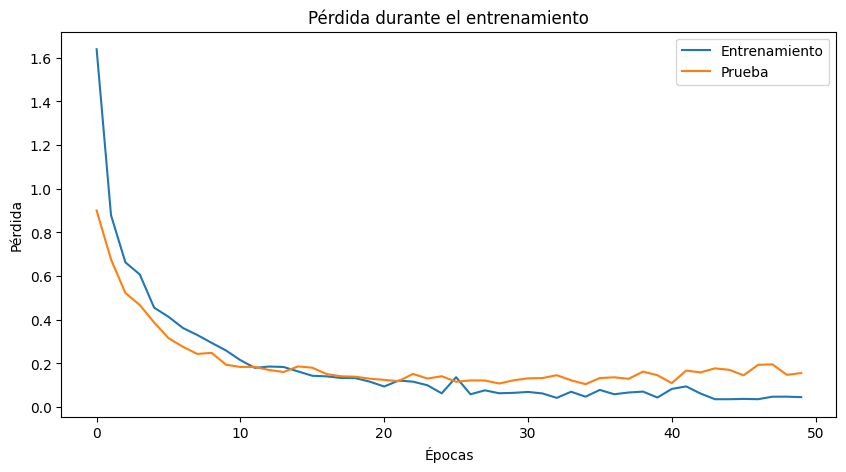

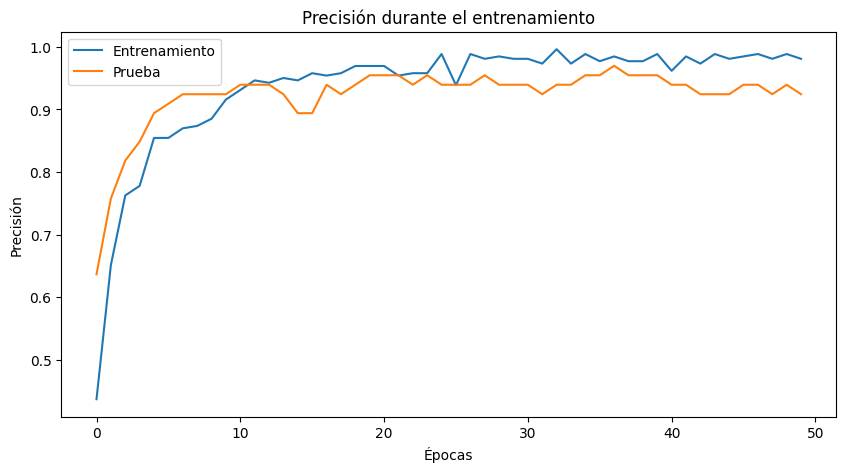

In [11]:
# Gráfica de la pérdida
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Entrenamiento')
plt.plot(test_losses, label='Prueba')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Gráfica de la precisión
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Entrenamiento')
plt.plot(test_accuracies, label='Prueba')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()


Época 1/50, Pérdida de entrenamiento: 1.5431, Precisión de entrenamiento: 0.4943, Pérdida de prueba: 0.9157, Precisión de prueba: 0.6818
Época 2/50, Pérdida de entrenamiento: 0.9646, Precisión de entrenamiento: 0.6782, Pérdida de prueba: 0.6100, Precisión de prueba: 0.7576
Época 3/50, Pérdida de entrenamiento: 0.6411, Precisión de entrenamiento: 0.7586, Pérdida de prueba: 0.4955, Precisión de prueba: 0.8030
Época 4/50, Pérdida de entrenamiento: 0.5875, Precisión de entrenamiento: 0.8046, Pérdida de prueba: 0.4094, Precisión de prueba: 0.8636
Época 5/50, Pérdida de entrenamiento: 0.4532, Precisión de entrenamiento: 0.8391, Pérdida de prueba: 0.3605, Precisión de prueba: 0.8636
Época 6/50, Pérdida de entrenamiento: 0.4125, Precisión de entrenamiento: 0.8889, Pérdida de prueba: 0.3150, Precisión de prueba: 0.8788
Época 7/50, Pérdida de entrenamiento: 0.3397, Precisión de entrenamiento: 0.8774, Pérdida de prueba: 0.3012, Precisión de prueba: 0.8636
Época 8/50, Pérdida de entrenamiento: 0.3

/var/folders/sj/nh7_122145n2cmvxt28lm3rc0000gn/T/ipykernel_2129/2950593173.py:251: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model

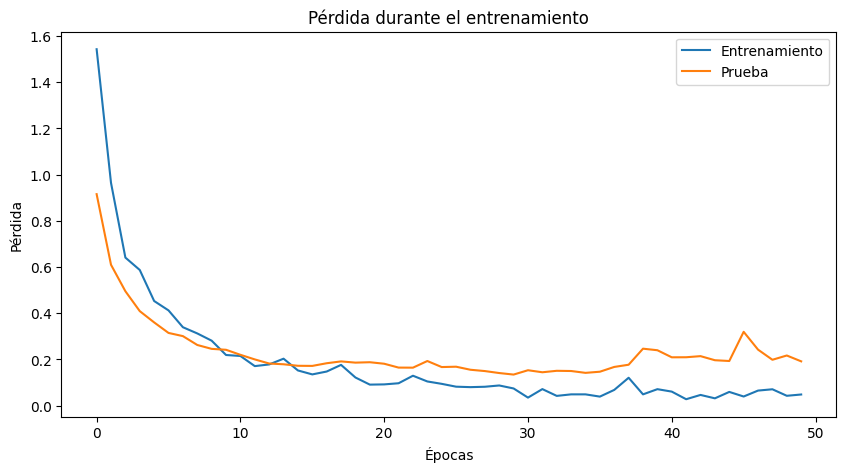

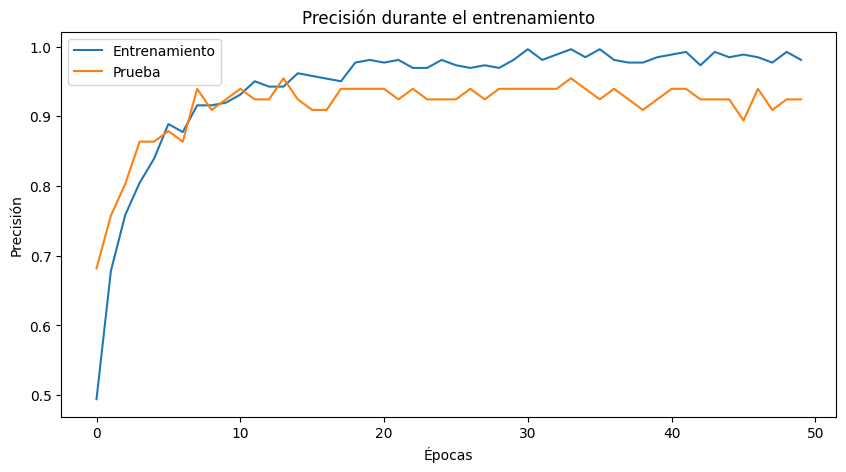

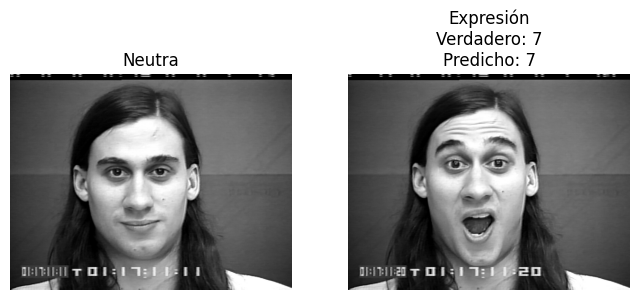

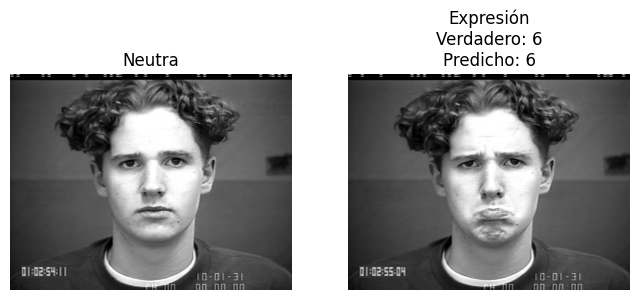

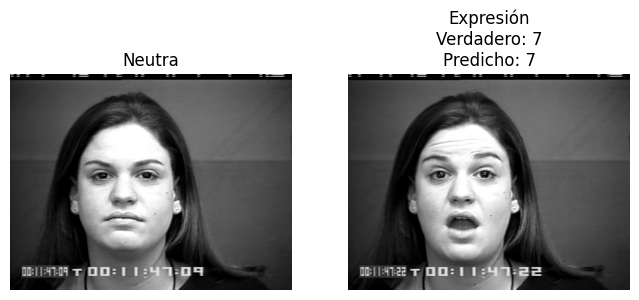

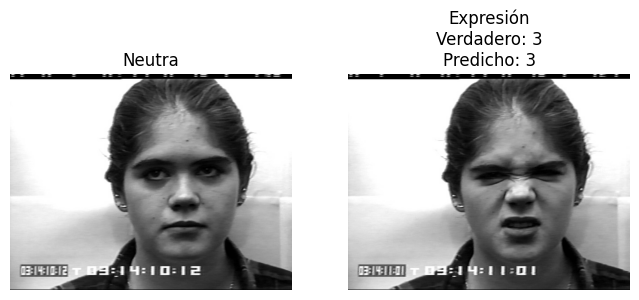

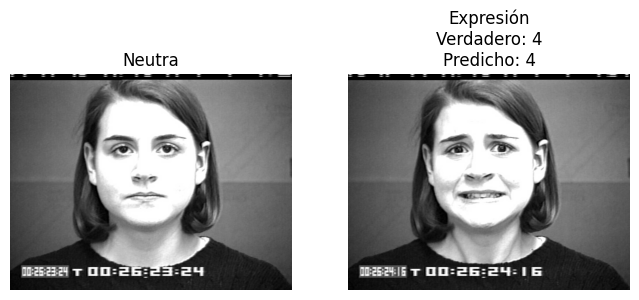

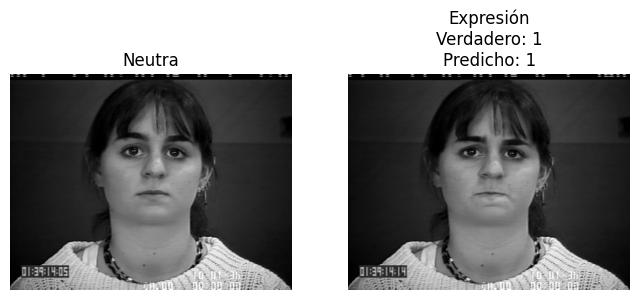

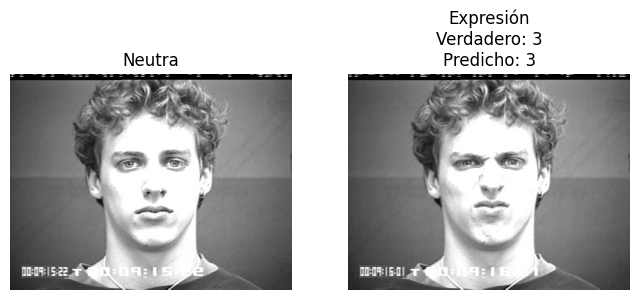

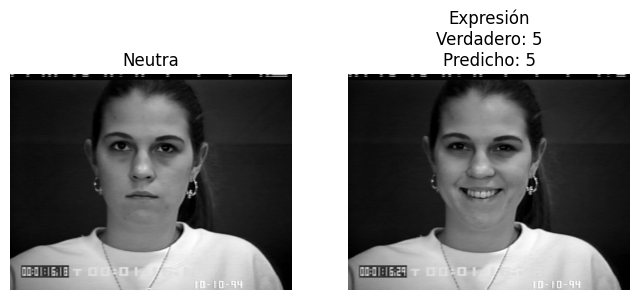

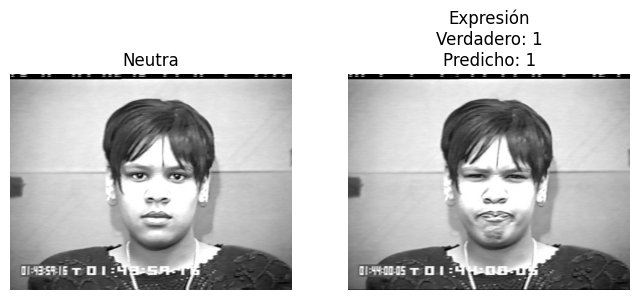

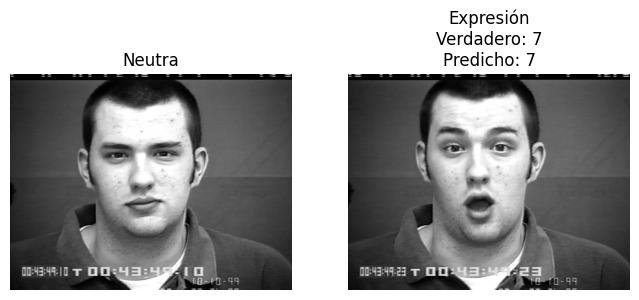

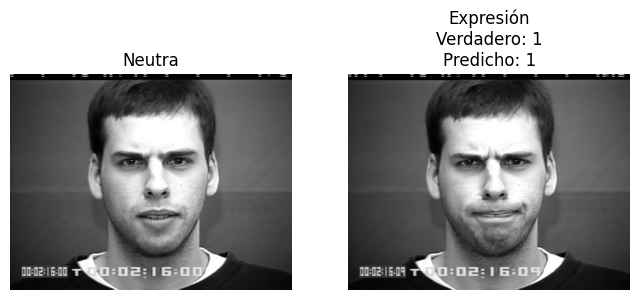

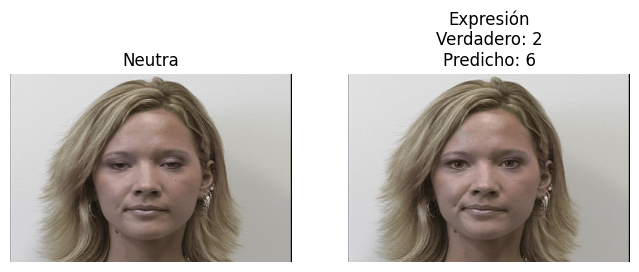

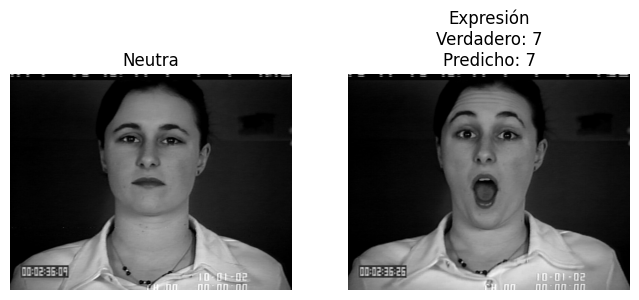

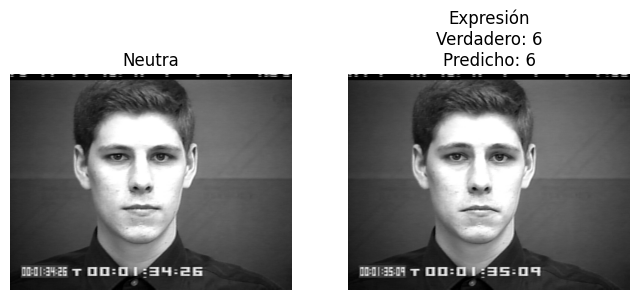

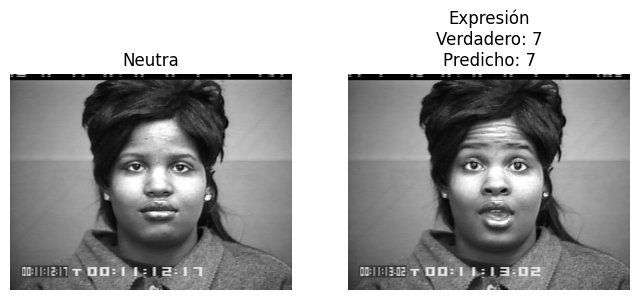

In [12]:
import os
import re
import cv2
import dlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

def ordenar_numerico(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def leer_datos(ruta_base):
    datos = []
    
    for dir_act, subdirs, archivos in os.walk(ruta_base):
        subdirs[:] = [d for d in subdirs if not d.startswith('.')]
        archivos = [f for f in archivos if not f.startswith('.')]
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        
        for arch in archivos:
            if arch.endswith('.txt'):
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip()
                    try:
                        valor = int(float(valor))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel)
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]
                    imgs.sort(key=ordenar_numerico)
                    
                    if imgs:
                        ruta_img_neutra = os.path.join(dir_img, imgs[0])  # Primera imagen (neutra)
                        ruta_img_expresion = os.path.join(dir_img, imgs[-1])  # Última imagen (máxima expresión)
                        datos.append((ruta_img_neutra, ruta_img_expresion, valor))
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    return datos

# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

def extraer_puntos(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen, 1)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos
    return None

def centrar_pts(pts):
    ojo_izq = np.mean(pts[36:42], axis=0)
    ojo_der = np.mean(pts[42:48], axis=0)
    punto_central = (ojo_izq + ojo_der) / 2
    pts_centrados = pts - punto_central
    return pts_centrados

def extraer_landmarks(datos):
    lista_dif = []
    lista_emo = []
    lista_ruta_img_neutra = []
    lista_ruta_img_expresion = []
    
    for item in datos:
        if len(item) != 3:
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img_neutra, ruta_img_expresion, emo = item
        pts_neutros = extraer_puntos(ruta_img_neutra)
        pts_expresion = extraer_puntos(ruta_img_expresion)

        if pts_neutros is not None and pts_expresion is not None:
            pts_neutros = np.array(pts_neutros)
            pts_expresion = np.array(pts_expresion)
            pts_neutros_centrados = centrar_pts(pts_neutros)
            pts_expresion_centrados = centrar_pts(pts_expresion)
            dif = pts_expresion_centrados - pts_neutros_centrados  # Calculamos la diferencia
            lista_dif.append(dif.flatten())  # Aplanamos para tener un vector
            lista_emo.append(emo)
            lista_ruta_img_neutra.append(ruta_img_neutra)
            lista_ruta_img_expresion.append(ruta_img_expresion)
        else:
            print(f"No se pudieron extraer puntos de {ruta_img_neutra} o {ruta_img_expresion}")

    if not lista_dif:
        print("No se extrajeron diferencias de puntos.")
        return None, None, None, None

    X = np.array(lista_dif)
    y = np.array(lista_emo)
    return X, y, lista_ruta_img_neutra, lista_ruta_img_expresion

# Ruta base de las etiquetas
ruta_base = 'Emotion'

# Leer los datos
datos = leer_datos(ruta_base)

# Extraer los landmarks y las emociones
X, y, paths_neutra, paths_expresion = extraer_landmarks(datos)

# Mapeamos las emociones a etiquetas desde 0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividimos en conjunto de entrenamiento y prueba, incluyendo las rutas de las imágenes
X_train, X_test, y_train, y_test, paths_neutra_train, paths_neutra_test, paths_expresion_train, paths_expresion_test = train_test_split(
    X, y_encoded, paths_neutra, paths_expresion, test_size=0.2, random_state=42, stratify=y_encoded)

# Convertimos a tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Creamos datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creamos DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

class EmotionClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(EmotionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out

input_size = X_train.shape[1]
num_classes = len(np.unique(y_encoded))
model = EmotionClassifier(input_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += target.size(0)
        correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += target.size(0)
            correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc

# Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_epochs = 50
best_accuracy = 0.0

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f"Época {epoch+1}/{num_epochs}, Pérdida de entrenamiento: {train_loss:.4f}, Precisión de entrenamiento: {train_acc:.4f}, Pérdida de prueba: {test_loss:.4f}, Precisión de prueba: {test_acc:.4f}")

# Cargar el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Pérdida en el conjunto de prueba: {test_loss:.4f}, Precisión en el conjunto de prueba: {test_acc:.4f}")

# Gráfica de la pérdida
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Entrenamiento')
plt.plot(test_losses, label='Prueba')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Gráfica de la precisión
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Entrenamiento')
plt.plot(test_accuracies, label='Prueba')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Función para visualizar las predicciones
def visualizar_predicciones(model, X_test, y_test, paths_neutra_test, paths_expresion_test, le, device, num_muestras=15):
    model.eval()
    with torch.no_grad():
        indices = np.random.choice(len(X_test), num_muestras, replace=False)
        for idx in indices:
            data = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            predicted_label = predicted.item()
            true_label = y_test[idx]
            # Obtener los nombres de las emociones
            predicted_emotion = le.inverse_transform([predicted_label])[0]
            true_emotion = le.inverse_transform([true_label])[0]
            # Leer las imágenes
            img_neutra = cv2.imread(paths_neutra_test[idx])
            img_expresion = cv2.imread(paths_expresion_test[idx])
            # Convertir imágenes de BGR a RGB
            img_neutra = cv2.cvtColor(img_neutra, cv2.COLOR_BGR2RGB)
            img_expresion = cv2.cvtColor(img_expresion, cv2.COLOR_BGR2RGB)
            # Mostrar las imágenes con etiquetas
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1)
            plt.imshow(img_neutra)
            plt.title('Neutra')
            plt.axis('off')
            plt.subplot(1,2,2)
            plt.imshow(img_expresion)
            plt.title(f'Expresión\nVerdadero: {true_emotion}\nPredicho: {predicted_emotion}')
            plt.axis('off')
            plt.show()

# Visualizar algunas predicciones
visualizar_predicciones(model, X_test, y_test, paths_neutra_test, paths_expresion_test, le, device, num_muestras=15)
